0: ─╭AngleEmbedding(M0)─╭BasicEntanglerLayers(M1)─╭AngleEmbedding(M2)†─┤ ╭<|0000⟩⟨0000|>
1: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─├AngleEmbedding(M2)†─┤ ├<|0000⟩⟨0000|>
2: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─├AngleEmbedding(M2)†─┤ ├<|0000⟩⟨0000|>
3: ─╰AngleEmbedding(M0)─╰BasicEntanglerLayers(M1)─╰AngleEmbedding(M2)†─┤ ╰<|0000⟩⟨0000|>

M0 = 
[2.44656504e-03 3.11712455e+00 1.93987537e+00 1.92156508e+00]
M1 = 
[[0. 0. 0. 0.]]
M2 = 
[0.02219945 0.07245275 1.64862822 1.25620029]


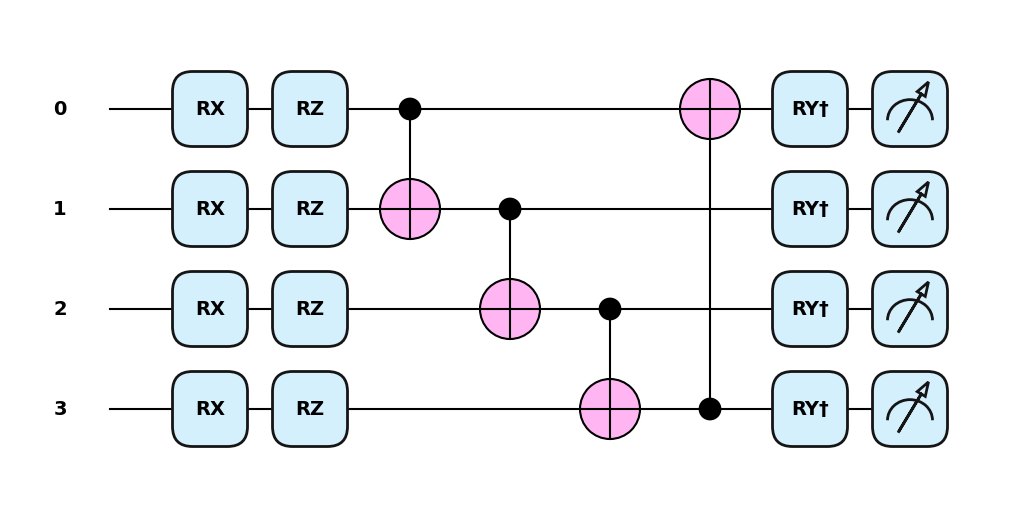

In [5]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

n_qubits = 4  # reduzir para visualização
x1_example = np.random.uniform(0, np.pi, n_qubits)
x2_example = np.random.uniform(0, np.pi, n_qubits)

dev_draw = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_draw)
def kernel(x1, x2):
    qml.AngleEmbedding(x1, wires=range(n_qubits), rotation="X")
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, n_qubits)),
        wires=range(n_qubits),
        rotation=qml.RZ
    )
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(n_qubits), rotation="Y")
    return qml.expval(qml.Projector([0] * n_qubits, wires=range(n_qubits)))

print(qml.draw(kernel_draw)(x1_example, x2_example))
fig, ax = qml.draw_mpl(
    kernel_draw,
    style="pennylane",
    wire_order=list(range(n_qubits)),
    show_all_wires=True,
    level="device",
)(x1_example, x2_example)
plt.savefig("angle_embedding_full.png", dpi=160, bbox_inches='tight')
plt.show()

/tmp/ipykernel_579096/2236267136.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


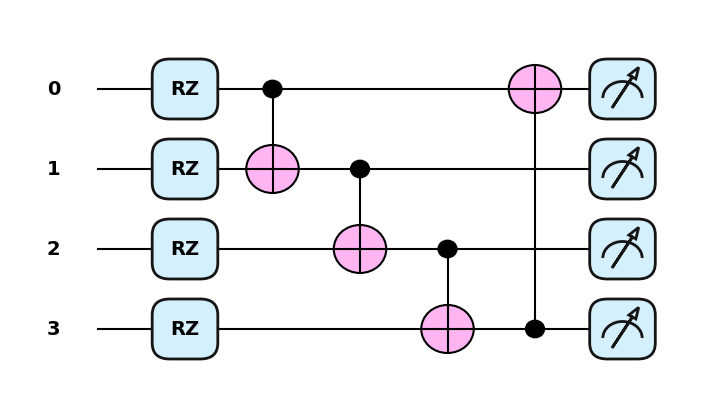

In [7]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def entangler_circuit():
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, n_qubits)),
        wires=range(n_qubits),
        rotation=qml.RZ
    )
    return qml.expval(qml.Projector([0] * n_qubits, wires=range(n_qubits)))

fig, ax = qml.draw_mpl(
    entangler_circuit,
    style="pennylane",
    wire_order=list(range(n_qubits)),
    show_all_wires=True,
    level="device",   # <-- expande em RZ + CNOT
    show_all_operations=True  # <-- mostra as operações individuais
)()

fig.set_size_inches(7, 4)
plt.tight_layout()
plt.savefig("basic_entangler_layers.png", dpi=160, bbox_inches='tight')
plt.show()

/tmp/ipykernel_579096/3261088662.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


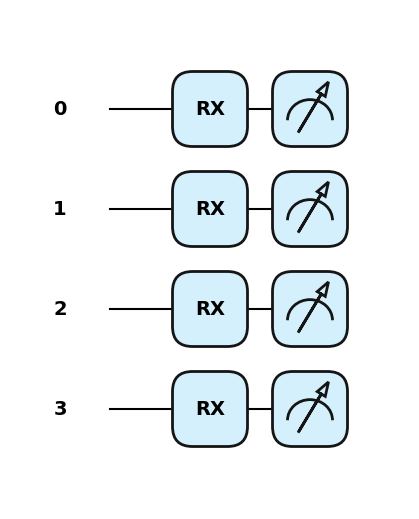

In [2]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

n_qubits = 4
np.random.seed(42)
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def angle_circuit():
    qml.AngleEmbedding(x_example, wires=range(n_qubits), rotation="X")
    return qml.expval(qml.Projector([0] * n_qubits, wires=range(n_qubits)))

fig, ax = qml.draw_mpl(
    angle_circuit,
    style="pennylane",
    wire_order=list(range(n_qubits)),
    show_all_wires=True,
    level="device",  # <-- expande em RX individuais
)()

fig.set_size_inches(4, 5)
plt.tight_layout()
plt.savefig("angle_embedding.png", dpi=160, bbox_inches='tight')
plt.show()

/tmp/ipykernel_579096/3321173176.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


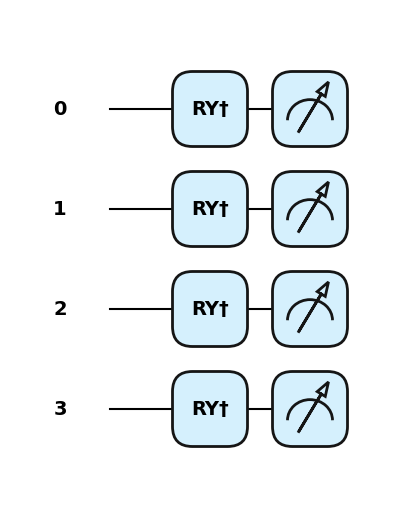

In [3]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

n_qubits = 4
np.random.seed(42)
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def angle_circuit():
    qml.adjoint(qml.AngleEmbedding)(x_example, wires=range(n_qubits), rotation="Y")
    return qml.expval(qml.Projector([0] * n_qubits, wires=range(n_qubits)))

fig, ax = qml.draw_mpl(
    angle_circuit,
    style="pennylane",
    wire_order=list(range(n_qubits)),
    show_all_wires=True,
    level="device",  # <-- expande em RX individuais
)()

fig.set_size_inches(4, 5)
plt.tight_layout()
plt.savefig("angle_embedding_adjoint.png", dpi=160, bbox_inches='tight')
plt.show()

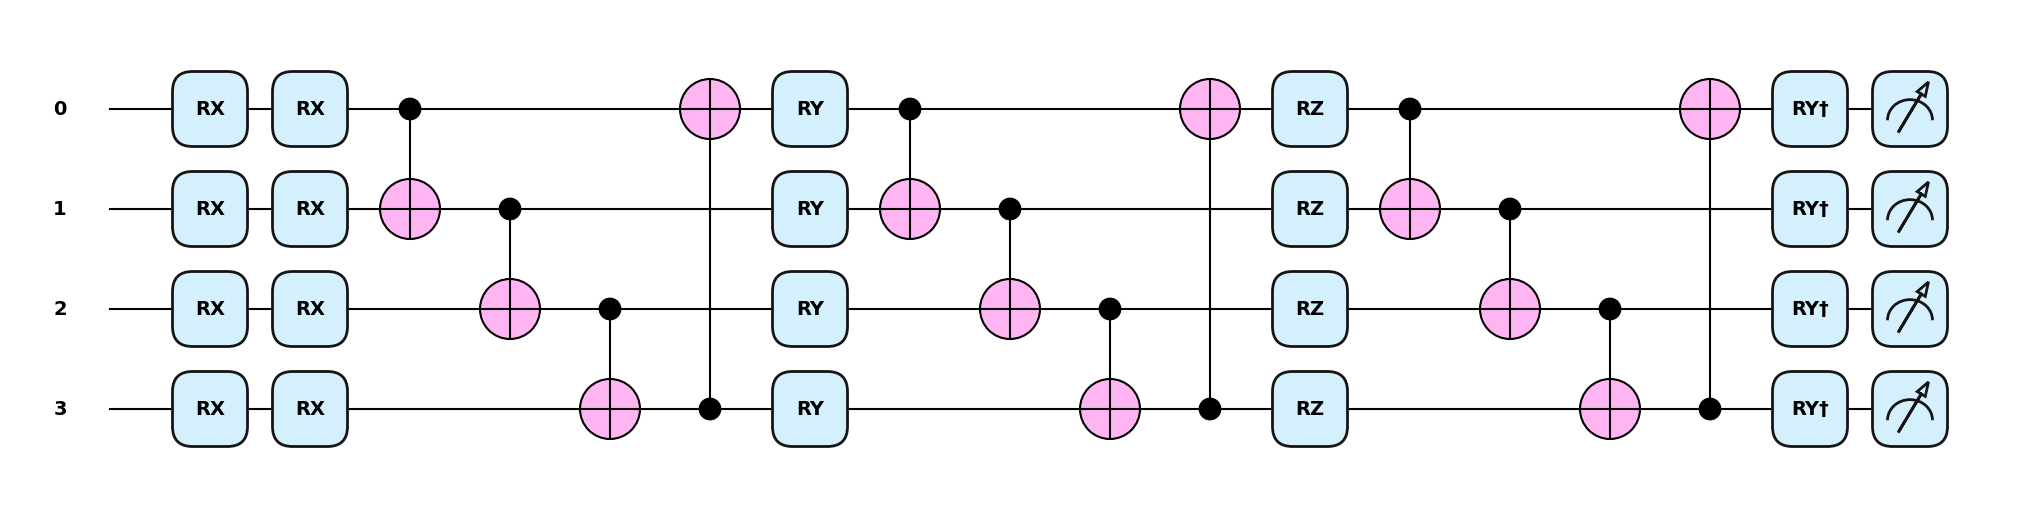

In [9]:
from mpmath import grampoint, siegeltheta, siegelz
import numpy as np
import pennylane as qml


def _gram_weights(n_qubits):
    points = [float(grampoint(n)) for n in range(n_qubits + 1)]
    return np.diff(points) % (2 * np.pi)


def _theta_weights(n_qubits, t_min=14.0, t_max=50.0):
    t_grid = np.linspace(t_min, t_max, n_qubits)
    theta = np.array([float(siegeltheta(t)) for t in t_grid])
    return np.gradient(theta) % (2 * np.pi)


def _hardy_weights(n_qubits, t_min=14.0, t_max=50.0):
    t_grid = np.linspace(t_min, t_max, n_qubits)
    z = np.array([float(siegelz(t)) for t in t_grid])
    return 2 * np.pi * (z - z.min()) / (z.max() - z.min())


_ROTATION_MAP = {
    "gram":  (qml.RX, _gram_weights),
    "theta": (qml.RY, _theta_weights),
    "hardy": (qml.RZ, _hardy_weights),
}
sources=("gram", "theta", "hardy")
layers = []
for src in sources:
    if src not in _ROTATION_MAP:
        raise ValueError(f"Fonte desconhecida '{src}'. Opções: {list(_ROTATION_MAP)}")
    gate, weight_fn = _ROTATION_MAP[src]
    layers.append((gate, weight_fn(n_qubits)))

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def kernel_fn(x1, x2):
    qml.AngleEmbedding(x1, wires=range(n_qubits), rotation='X')

    for gate, weights in layers:
        for i in range(n_qubits):
            gate(weights[i], wires=i)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])

    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(n_qubits), rotation='Y')
    return qml.expval(qml.Projector([0] * n_qubits, wires=range(n_qubits)))


n_qubits = 4  # reduzir para visualização
x1_example = np.random.uniform(0, np.pi, n_qubits)
x2_example = np.random.uniform(0, np.pi, n_qubits)

fig, ax = qml.draw_mpl(
    kernel_fn,
    style="pennylane",
    wire_order=list(range(n_qubits)),
    show_all_wires=True,
    level="device",
    show_all_operations=True
)(x1_example, x2_example)
plt.savefig("angle_embedding_full.png", dpi=160, bbox_inches='tight')
plt.show()